# 04a_W: Women's Feature Building

**Same pipeline as men's 04a, adapted for women's data.**

### Key Differences from Men's
- No Massey Ordinals (POM, SAG, Composite rankings are men's only)
- Detailed box scores start from **2010** (vs 2003 for men)
- Team IDs range: 3101-3481

### Features Built Here (15 total, vs 18 for men's)

| # | Feature | Source |
|---|---------|--------|
| 1 | `WinPct` | Regular season results |
| 2 | `AvgPointsFor` | Regular season results |
| 3 | `AvgPointsAgainst` | Regular season results |
| 4 | `AvgMargin` | Regular season results |
| 5 | `eFG_Off` | Detailed box scores |
| 6 | `TORate_Off` | Detailed box scores |
| 7 | `ORBRate_Off` | Detailed box scores |
| 8 | `FTRate_Off` | Detailed box scores |
| 9 | `Elo_RegSeason` | Calculated from games |
| 10 | `SeedNum` | Tournament seeds (1-16, 100=unseeded) |
| 11 | `IsSeeded` | Binary: made tournament |
| 12 | `ConfStrength_Rank` | Conference + Elo |
| 13 | `Last15WinPct` | Last 15 regular season games |
| 14 | `Last15AvgMargin` | Last 15 regular season games |
| 15 | `ConfTourneyChamp` | Conference tourney winner |

**Output:** `processed/team_features_W.csv`

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import (
    load_regular_season_results, load_tourney_results,
    load_seeds, load_teams,
    load_team_conferences, load_conference_tourney_games,
    PROCESSED_DIR
)
from src.features import (
    calculate_team_season_stats, calculate_seed_features,
    calculate_four_factors, aggregate_four_factors,
    calculate_elo_ratings, calculate_conference_strength,
    calculate_last_n_games, calculate_conf_tourney_champ
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)

GENDER = 'W'
YEAR_START = 2010  # Women's detailed data starts here

teams = load_teams(GENDER)
team_lookup = dict(zip(teams['TeamID'], teams['TeamName']))
print(f"Women's teams: {len(teams)}")
print(f"TeamID range: {teams['TeamID'].min()}-{teams['TeamID'].max()}")
print(f"Using data from {YEAR_START} onwards")

Women's teams: 379
TeamID range: 3101-3481
Using data from 2010 onwards


---
## 1. Basic Season Stats

In [2]:
regular = load_regular_season_results(GENDER)
regular = regular[regular['Season'] >= YEAR_START]
print(f"Regular season games: {len(regular):,} ({regular['Season'].min()}-{regular['Season'].max()})")

basic_stats = calculate_team_season_stats(regular)
print(f"Basic stats: {basic_stats.shape[0]:,} team-seasons")
basic_stats.head()

Regular season games: 85,726 (2010-2026)
Basic stats: 5,966 team-seasons


,Season,TeamID,Games,Wins,Losses,WinPct,AvgPointsFor,AvgPointsAgainst,AvgMargin
0,2010,3102,28,1,27,0.035714,51.821429,71.785714,-19.964286
1,2010,3103,30,17,13,0.566667,62.233333,59.633333,2.600000
2,2010,3104,30,12,18,0.400000,64.033333,66.633333,-2.600000
3,2010,3105,27,14,13,0.518519,60.777778,64.740741,-3.962963
4,2010,3106,29,12,17,0.413793,55.137931,57.413793,-2.275862


---
## 2. Four Factors

In [3]:
detailed = load_regular_season_results(GENDER, detailed=True)
detailed = detailed[detailed['Season'] >= YEAR_START]
print(f"Detailed games: {len(detailed):,} ({detailed['Season'].min()}-{detailed['Season'].max()})")

four_factors_games = calculate_four_factors(detailed)
four_factors = aggregate_four_factors(four_factors_games)
print(f"Four Factors: {four_factors.shape[0]:,} team-seasons")
print(f"NaN count: {four_factors.isnull().sum().sum()}")
four_factors.head()

Detailed games: 85,505 (2010-2026)
Four Factors: 5,965 team-seasons
NaN count: 0


,Season,TeamID,eFG_Off,TORate_Off,ORBRate_Off,FTRate_Off
0,2010,3102,0.456953,0.208985,0.355622,0.241503
1,2010,3103,0.437032,0.226632,0.388839,0.257255
2,2010,3104,0.451132,0.219739,0.360259,0.175776
3,2010,3105,0.435253,0.289247,0.384812,0.349841
4,2010,3106,0.383984,0.238855,0.394967,0.315263


---
## 3. Elo Ratings

Calculating Elo ratings...
Elo ratings: 5,966 team-seasons


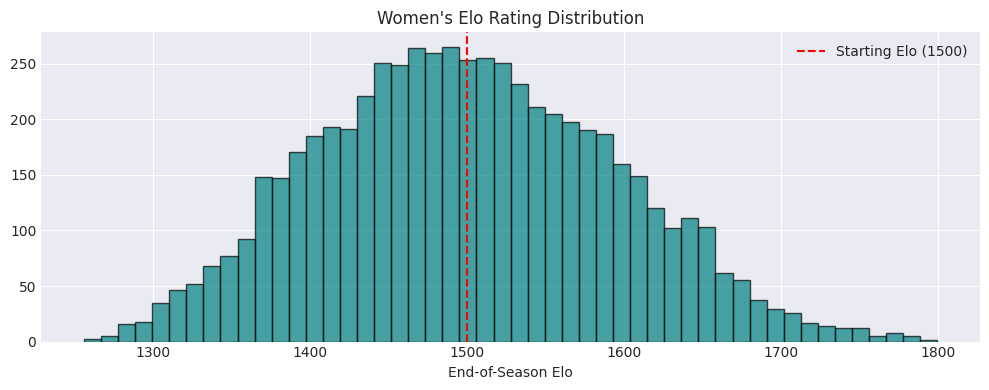

In [4]:
print("Calculating Elo ratings...")
elo_history = calculate_elo_ratings(regular)

# End-of-regular-season Elo
elo_final = elo_history.sort_values('DayNum').groupby(['Season', 'TeamID']).tail(1)
elo_final = elo_final[['Season', 'TeamID', 'Elo']].rename(columns={'Elo': 'Elo_RegSeason'})
print(f"Elo ratings: {elo_final.shape[0]:,} team-seasons")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(elo_final['Elo_RegSeason'], bins=50, edgecolor='black', alpha=0.7, color='teal')
ax.axvline(1500, color='red', linestyle='--', label='Starting Elo (1500)')
ax.set_xlabel('End-of-Season Elo')
ax.set_title("Women's Elo Rating Distribution")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Conference Strength

In [5]:
conferences = load_team_conferences(GENDER)
conferences = conferences[conferences['Season'] >= YEAR_START]
print(f"Conference assignments: {len(conferences):,} rows")

conf_strength = calculate_conference_strength(conferences, elo_final)
print(f"Conference strength: {len(conf_strength):,} team-seasons")

# Show top conferences for latest year
latest = conf_strength['Season'].max()
conf_latest = conf_strength[conf_strength['Season'] == latest].drop_duplicates('ConfAbbrev').sort_values('ConfStrength_Rank')
print(f"\n{latest} Top 10 Women's Conferences:")
for _, row in conf_latest.head(10).iterrows():
    print(f"  #{int(row['ConfStrength_Rank']):2d}  {row['ConfAbbrev']}")

Conference assignments: 5,968 rows
Conference strength: 5,968 team-seasons

2026 Top 10 Women's Conferences:
  # 1  sec
  # 2  big_ten
  # 3  big_twelve
  # 4  acc
  # 5  big_east
  # 6  ivy
  # 7  a_ten
  # 8  sun_belt
  # 9  aac
  #10  aec


---
## 5. Last 15 Games (Momentum)

In [6]:
last15 = calculate_last_n_games(regular, n=15)
print(f"Last 15 stats: {len(last15):,} team-seasons")

comparison = basic_stats.merge(last15, on=['Season', 'TeamID'])
print(f"Season WinPct vs Last15 WinPct correlation: {comparison['WinPct'].corr(comparison['Last15WinPct']):.3f}")
print(f"Season AvgMargin vs Last15 AvgMargin correlation: {comparison['AvgMargin'].corr(comparison['Last15AvgMargin']):.3f}")

Last 15 stats: 5,966 team-seasons
Season WinPct vs Last15 WinPct correlation: 0.896
Season AvgMargin vs Last15 AvgMargin correlation: 0.879


---
## 6. Conference Tournament Champion

In [7]:
conf_tourney = load_conference_tourney_games(GENDER)
conf_tourney = conf_tourney[conf_tourney['Season'] >= YEAR_START]
print(f"Conference tournament games: {len(conf_tourney):,}")
print(f"Seasons: {conf_tourney['Season'].min()} to {conf_tourney['Season'].max()}")

conf_champs = calculate_conf_tourney_champ(conf_tourney)
print(f"Conference champions: {len(conf_champs):,} team-seasons")

Conference tournament games: 4,452
Seasons: 2010 to 2025
Conference champions: 498 team-seasons


---
## 7. Tournament Seeds

In [8]:
seeds = load_seeds(GENDER)
seeds = seeds[seeds['Season'] >= YEAR_START]
seed_features = calculate_seed_features(seeds)
print(f"Seed features: {seed_features.shape[0]} team-seasons")
print(f"Seeds per season: ~{seed_features.shape[0] // seeds['Season'].nunique()}")
seed_features.head()

Seed features: 976 team-seasons
Seeds per season: ~65


,Season,TeamID,Seed,Region,SeedNum,IsPlayIn
768,2010,3163,W01,W,1,False
769,2010,3326,W02,W,2,False
770,2010,3199,W03,W,3,False
771,2010,3235,W04,W,4,False
772,2010,3438,W05,W,5,False


---
## 8. Merge All Features

In [9]:
team_features = basic_stats.copy()
team_features = team_features.merge(four_factors, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(elo_final, on=['Season', 'TeamID'], how='left')

# Seeds
team_features = team_features.merge(
    seed_features[['Season', 'TeamID', 'SeedNum']],
    on=['Season', 'TeamID'], how='left'
)
team_features['IsSeeded'] = team_features['SeedNum'].notna().astype(int)
team_features['SeedNum'] = team_features['SeedNum'].fillna(100)

# Conference strength
team_features = team_features.merge(
    conf_strength[['Season', 'TeamID', 'ConfStrength_Rank']],
    on=['Season', 'TeamID'], how='left'
)

# Last 15 games
team_features = team_features.merge(last15, on=['Season', 'TeamID'], how='left')

# Conference tournament champion
team_features = team_features.merge(conf_champs, on=['Season', 'TeamID'], how='left')
team_features['ConfTourneyChamp'] = team_features['ConfTourneyChamp'].fillna(0).astype(int)

print(f"Final women's team features: {team_features.shape}")
print(f"Seasons: {team_features['Season'].min()} to {team_features['Season'].max()}")
print(f"\nColumns: {team_features.columns.tolist()}")
print(f"\nData completeness:")
for col in team_features.columns:
    pct = 100 * team_features[col].notna().sum() / len(team_features)
    print(f"  {col}: {pct:.0f}%")

Final women's team features: (5966, 20)
Seasons: 2010 to 2026

Columns: ['Season', 'TeamID', 'Games', 'Wins', 'Losses', 'WinPct', 'AvgPointsFor', 'AvgPointsAgainst', 'AvgMargin', 'eFG_Off', 'TORate_Off', 'ORBRate_Off', 'FTRate_Off', 'Elo_RegSeason', 'SeedNum', 'IsSeeded', 'ConfStrength_Rank', 'Last15WinPct', 'Last15AvgMargin', 'ConfTourneyChamp']

Data completeness:
  Season: 100%
  TeamID: 100%
  Games: 100%
  Wins: 100%
  Losses: 100%
  WinPct: 100%
  AvgPointsFor: 100%
  AvgPointsAgainst: 100%
  AvgMargin: 100%
  eFG_Off: 100%
  TORate_Off: 100%
  ORBRate_Off: 100%
  FTRate_Off: 100%
  Elo_RegSeason: 100%
  SeedNum: 100%
  IsSeeded: 100%
  ConfStrength_Rank: 100%
  Last15WinPct: 100%
  Last15AvgMargin: 100%
  ConfTourneyChamp: 100%


In [10]:
# Sanity check: 2025 top women's teams
top_2025 = team_features[team_features['Season'] == 2025].sort_values('Elo_RegSeason', ascending=False).head(15)
top_2025['TeamName'] = top_2025['TeamID'].map(team_lookup)
display(top_2025[['TeamName', 'WinPct', 'AvgMargin', 'Elo_RegSeason',
                  'SeedNum', 'ConfStrength_Rank', 'Last15AvgMargin', 'ConfTourneyChamp']])

,TeamName,WinPct,AvgMargin,Elo_RegSeason,SeedNum,ConfStrength_Rank,Last15AvgMargin,ConfTourneyChamp
5503,South Carolina,0.909091,22.727273,1761.042137,1.0,1,17.733333,1
5543,UCLA,0.937500,20.968750,1759.444868,1.0,2,11.400000,1
5526,Texas,0.911765,23.029412,1753.835619,1.0,1,12.000000,0
5551,USC,0.903226,21.612903,1743.179687,1.0,2,11.933333,0
5296,Connecticut,0.911765,28.970588,1741.071520,2.0,5,29.066667,1
5521,TCU,0.911765,20.294118,1739.876360,2.0,4,11.600000,1
5314,Duke,0.787879,15.727273,1719.353355,2.0,3,14.200000,1
5431,NC State,0.812500,11.406250,1701.138069,2.0,3,9.666667,0
5261,Baylor,0.794118,17.970588,1691.317097,4.0,4,11.000000,0
5346,Grand Canyon,0.937500,17.906250,1687.909425,13.0,19,22.200000,1


---
## 9. Save

In [11]:
team_features.to_csv(PROCESSED_DIR / 'team_features_W.csv', index=False)
print(f"Saved: processed/team_features_W.csv ({team_features.shape})")
print(f"\nNext: Run 04b_W_matchup_building.ipynb")

Saved: processed/team_features_W.csv ((5966, 20))

Next: Run 04b_W_matchup_building.ipynb
